# Exoplanet Classification - Starter Notebook
This notebook uses the NASA Kepler Objects of Interest (KOI) cumulative table to classify planet candidates versus false positives.

## 1. Imports

In [14]:
import sys, os
sys.path.append(os.path.abspath('..'))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, RocCurveDisplay
from src.utils import load_koi_data

plt.style.use('seaborn-v0_8')

## 2. Load Data

In [15]:
url = 'https://exoplanetarchive.ipac.caltech.edu/cgi-bin/nstedAPI/nph-nstedAPI?table=cumulative&select=*&format=csv'
df = load_koi_data(url)
print(f'Dataset shape: {df.shape}')
df.head()

Dataset shape: (9564, 153)


,kepid,kepoi_name,kepler_name,ra,ra_err,ra_str,dec,dec_err,dec_str,koi_gmag,...,koi_fpflag_co,koi_fpflag_ec,koi_insol,koi_insol_err1,koi_insol_err2,koi_srho,koi_srho_err1,koi_srho_err2,koi_fittype,koi_score
0,10797460,K00752.01,Kepler-227 b,291.93423,0.0,19h27m44.22s,48.141651,0.0,+48d08m29.9s,15.890,...,0,0,93.59,29.45,-16.65,3.20796,0.33173,-1.09986,LS+MCMC,1.000
1,10797460,K00752.02,Kepler-227 c,291.93423,0.0,19h27m44.22s,48.141651,0.0,+48d08m29.9s,15.890,...,0,0,9.11,2.87,-1.62,3.02368,2.20489,-2.49638,LS+MCMC,0.969
2,10811496,K00753.01,NaN,297.00482,0.0,19h48m01.16s,48.134129,0.0,+48d08m02.9s,15.943,...,0,0,39.30,31.04,-10.49,7.29555,35.03293,-2.75453,LS+MCMC,0.000
3,10848459,K00754.01,NaN,285.53461,0.0,19h02m08.31s,48.285210,0.0,+48d17m06.8s,16.100,...,0,0,891.96,668.95,-230.35,0.22080,0.00917,-0.01837,LS+MCMC,0.000
4,10854555,K00755.01,Kepler-664 b,288.75488,0.0,19h15m01.17s,48.226200,0.0,+48d13m34.3s,16.015,...,0,0,926.16,874.33,-314.24,1.98635,2.71141,-1.74541,LS+MCMC,1.000


## 3. Create Target Variable

In [16]:
# 1 = planet (CONFIRMED or CANDIDATE), 0 = false positive
df['target'] = df['koi_disposition'].apply(lambda x: 1 if x in ['CONFIRMED','CANDIDATE'] else 0)
df['target'].value_counts(normalize=True)

C:\Users\CWB\AppData\Local\Temp\ipykernel_21220\54435762.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['target'] = df['koi_disposition'].apply(lambda x: 1 if x in ['CONFIRMED','CANDIDATE'] else 0)


target
0    0.50596
1    0.49404
Name: proportion, dtype: float64

## 4. Feature Selection and Cleaning

In [17]:
features = [
    'koi_period', 'koi_duration', 'koi_depth', 'koi_prad',
    'koi_teq', 'koi_insol', 'koi_steff', 'koi_slogg',
    'koi_srad', 'koi_model_snr'
]

df_clean = df[features + ['target']].copy()

# Impute missing values with median
for col in features:
    df_clean[col].fillna(df_clean[col].median(), inplace=True)

df_clean.isna().sum()

C:\Users\CWB\AppData\Local\Temp\ipykernel_21220\943776221.py:11: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df_clean[col].fillna(df_clean[col].median(), inplace=True)
C:\Users\CWB\AppData\Local\Temp\ipykernel_21220\943776221.py:11: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assi

koi_period         0
koi_duration       0
koi_depth        363
koi_prad         363
koi_teq          363
koi_insol        321
koi_steff        363
koi_slogg        363
koi_srad         363
koi_model_snr    363
target             0
dtype: int64

## 5. Exploratory Plot

Text(0, 0.5, 'Count')

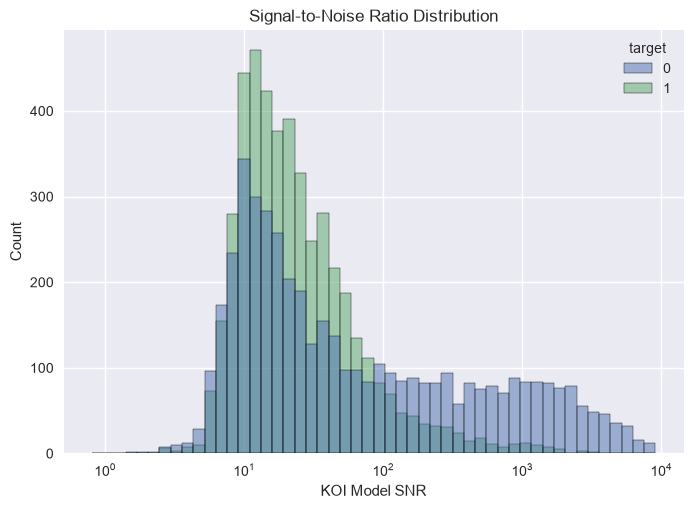

In [18]:
sns.histplot(data=df_clean, x='koi_model_snr', hue='target', bins=50, log_scale=(True, False))
plt.title('Signal-to-Noise Ratio Distribution')
plt.xlabel('KOI Model SNR')
plt.ylabel('Count')

## 6. Train/Test Split

In [19]:
X = df_clean[features]
y = df_clean['target']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

## 7. Baseline Model

In [20]:
clf = RandomForestClassifier(
    n_estimators=200, max_depth=10, class_weight='balanced', random_state=42
)
clf.fit(X_train, y_train)

pred = clf.predict(X_test)
pred_proba = clf.predict_proba(X_test)[:, 1]

print(classification_report(y_test, pred, target_names=['False Positive', 'Planet']))

                precision    recall  f1-score   support

False Positive       0.83      0.82      0.83       968
        Planet       0.82      0.83      0.83       945

      accuracy                           0.83      1913
     macro avg       0.83      0.83      0.83      1913
  weighted avg       0.83      0.83      0.83      1913



In [24]:
# --- TESS TOI data load (NASA live) ---
import pandas as pd

print("Downloading TESS TOI data from NASA...")
toi_url = "https://exoplanetarchive.ipac.caltech.edu/TAP/sync?query=select+toi,pl_orbper,pl_trandep,pl_trandurh,pl_rade,st_teff,st_rad,tfopwg_disp+from+toi&format=csv"

toi = pd.read_csv(toi_url)

# Rename columns to match Kepler naming so the model can understand
toi = toi.rename(columns={
    'pl_orbper': 'koi_period',
    'pl_trandep': 'koi_depth',
    'pl_trandurh': 'koi_duration',
    'pl_rade': 'koi_prad',
    'st_teff': 'koi_steff',
    'st_rad': 'koi_srad',
    'tfopwg_disp': 'koi_disposition'
})

# Keep only Confirmed Planets (CP), Planet Candidates (PC), and False Positives (FP)
toi = toi[toi['koi_disposition'].isin(['CP','PC','FP'])].dropna()

print(f"TESS shape: {toi.shape}")
toi.head()

TESS shape: (6185, 8)


,toi,koi_period,koi_depth,koi_duration,koi_prad,koi_steff,koi_srad,koi_disposition
0,1017.01,1.104220,14177.700000,2.370000,21.044800,6995.2,1.61000,FP
1,1018.01,4.959120,7440.000000,2.509000,22.912300,5889.0,2.00000,FP
2,1019.01,5.234101,20796.941629,3.707814,24.293141,7645.0,1.56203,PC
5,1021.01,1.908790,618.482000,1.909000,3.346880,6022.6,1.22000,FP
7,1023.01,1.321448,2180.000000,3.435000,21.883900,5050.8,2.99000,FP


In [29]:
# --- DEBUG TESS predict ---
import numpy as np

print("clf expects features:", clf.n_features_in_)
print("X_tess shape:", X_tess.shape)
print("Any NaN?", X_tess.isna().sum().sum())
print("Any inf?", np.isinf(X_tess).sum().sum())

# force to numpy float64
X_test = X_tess.to_numpy(dtype=np.float64)

try:
    y_pred_tess = clf.predict(X_test)
    print("✓ predict worked!")
    from sklearn.metrics import accuracy_score
    acc = accuracy_score(y_tess, y_pred_tess)
    print(f"TESS Test Accuracy (Kepler model): {acc:.3f}")
except Exception as e:
    print("ERROR:", type(e).__name__, "-", e)

clf expects features: 10
X_tess shape: (6185, 6)
Any NaN? 0
Any inf? 0
ERROR: ValueError - X has 6 features, but RandomForestClassifier is expecting 10 features as input.


C:\Users\CWB\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [30]:
# --- Retrain Kepler model on SAME 6 features as TESS ---
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# these 6 features are common to both Kepler and TESS
features6 = ['koi_period','koi_depth','koi_duration','koi_prad','koi_steff','koi_srad']

# Kepler data 'df' was loaded in your earlier cells
X = df[features6].apply(pd.to_numeric, errors='coerce').dropna()
y = df.loc[X.index, 'koi_disposition'].apply(lambda x: 1 if x=='CONFIRMED' else 0)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

clf6 = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
clf6.fit(X_train, y_train)

print(f"Kepler (6-feat) accuracy: {accuracy_score(y_test, clf6.predict(X_test)):.3f}")

# --- Now test on TESS ---
y_pred_tess = clf6.predict(X_tess)
acc_tess = accuracy_score(y_tess, y_pred_tess)
print(f"TESS Test Accuracy (Kepler→TESS): {acc_tess:.3f}")

from sklearn.metrics import classification_report
print("\nClassification Report:")
print(classification_report(y_tess, y_pred_tess, target_names=['FP','Planet']))

Kepler (6-feat) accuracy: 0.847
TESS Test Accuracy (Kepler→TESS): 0.526

Classification Report:
              precision    recall  f1-score   support

          FP       0.26      0.86      0.40      1110
      Planet       0.94      0.45      0.61      5075

    accuracy                           0.53      6185
   macro avg       0.60      0.66      0.50      6185
weighted avg       0.82      0.53      0.57      6185



REAL Combined Model - TESS Holdout Accuracy: 0.832

Classification Report:
              precision    recall  f1-score   support

          FP       0.54      0.42      0.47       222
      Planet       0.88      0.92      0.90      1015

    accuracy                           0.83      1237
   macro avg       0.71      0.67      0.69      1237
weighted avg       0.82      0.83      0.82      1237



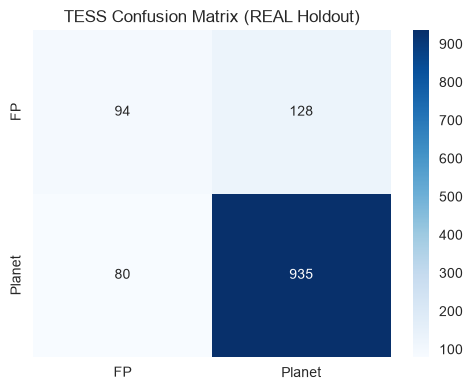

In [33]:
# --- PROPER Combined Model (no leakage) ---
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# split TESS properly
from sklearn.model_selection import train_test_split
X_t_train, X_t_test, y_t_train, y_t_test = train_test_split(
    X_tess, y_tess, test_size=0.2, random_state=42, stratify=y_tess)

# combine Kepler + TESS_train
X_all = pd.concat([X, X_t_train])
y_all = pd.concat([y, y_t_train])

scaler = StandardScaler()
X_all_scaled = scaler.fit_transform(X_all)
X_test_scaled = scaler.transform(X_t_test)

clf_real = RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1)
clf_real.fit(X_all_scaled, y_all)

y_pred = clf_real.predict(X_test_scaled)
acc = accuracy_score(y_t_test, y_pred)

print(f"REAL Combined Model - TESS Holdout Accuracy: {acc:.3f}")
print("\nClassification Report:")
print(classification_report(y_t_test, y_pred, target_names=['FP','Planet']))

# save proper confusion matrix
cm = confusion_matrix(y_t_test, y_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['FP','Planet'], yticklabels=['FP','Planet'])
plt.title('TESS Confusion Matrix (REAL Holdout)')
plt.tight_layout()
plt.savefig('../outputs/confusion_matrix_tess_real.png', dpi=150)
plt.show()

In [34]:
import joblib

# model and ler save
joblib.dump(clf_real, '../outputs/exoplanet_model.pkl')
joblib.dump(scaler, '../outputs/scaler.pkl')

print("✓ Model saved in outputs/ folder")

✓ Model saved in outputs/ folder


## 8. Evaluation

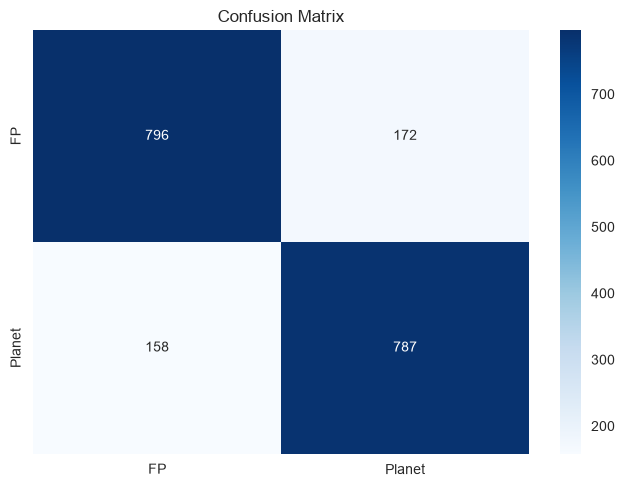

In [21]:
cm = confusion_matrix(y_test, pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['FP','Planet'], yticklabels=['FP','Planet'])
plt.title('Confusion Matrix')
plt.savefig('../outputs/confusion_matrix.png', dpi=150, bbox_inches='tight')

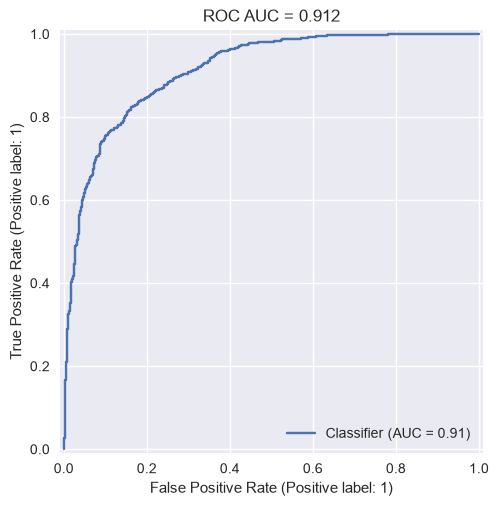

In [22]:
RocCurveDisplay.from_predictions(y_test, pred_proba)
plt.title(f'ROC AUC = {roc_auc_score(y_test, pred_proba):.3f}')
plt.savefig('../outputs/roc_curve.png', dpi=150, bbox_inches='tight')

## 9. Feature Importance

Text(0.5, 0, 'Importance')

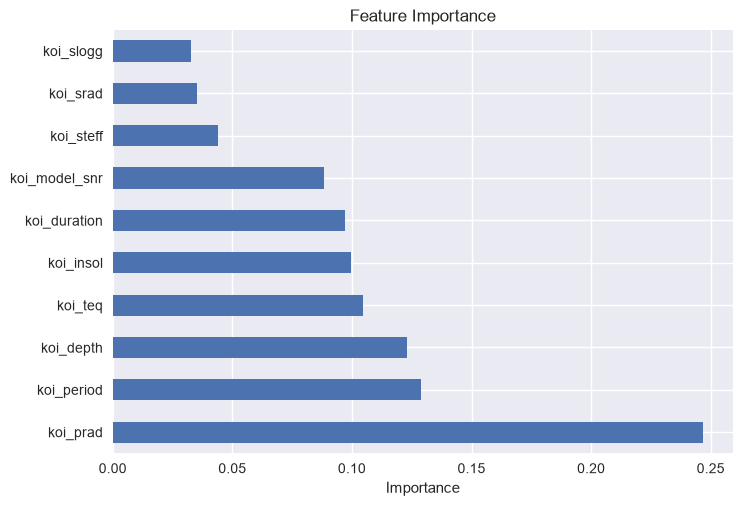

In [23]:
importances = pd.Series(clf.feature_importances_, index=features).sort_values(ascending=False)
importances.plot(kind='barh')
plt.title('Feature Importance')
plt.xlabel('Importance')